In [125]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

Loading *datasets*

In [126]:
stellar_mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
stellar_luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Dataset Visualization


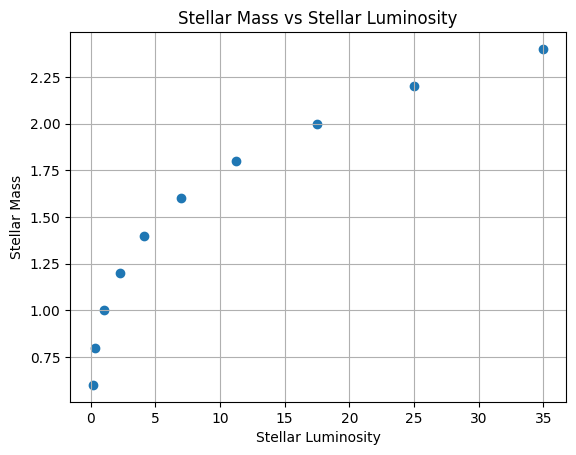

In [127]:
plt.scatter(stellar_luminosity, stellar_mass)
plt.xlabel("Stellar Luminosity")
plt.ylabel("Stellar Mass")
plt.title("Stellar Mass vs Stellar Luminosity")
plt.grid(True)
plt.show()

# Model and Loss

In [128]:
def predict(x, w, b):
    return w * x + b

def compute_cost(x, y, w, b):
    m = x.shape[0]
    y_hat = w * x + b
    errors = y_hat - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


For testing, we are going to estimate w and b and analyze the results.
We are going to calculte a mean slope and see the cost of our predictment.

w1 = (1.6 - 1.4) / (7 - 4.10) = 0.07
w2 = (1.8 - 1.4) / (11.2 - 4.10) = 0.0563
wmean = 0.06315

Now, just for eye we can notice that when stellar luminosity = 0, its mass can't be > 0.6 so for this case b = 0

In [129]:
w_test = 0.06315
b_test = 0.0
y_hat_test = predict(np.array(stellar_luminosity), w_test, b_test)
print("predictions with w=0.06315, b=0:", y_hat_test)
print("Cost with w=0.06315, b=0:", compute_cost(np.array(stellar_luminosity),
np.array(stellar_mass), w_test, b_test))

predictions with w=0.06315, b=0: [0.0095 0.0221 0.0631 0.1452 0.2589 0.442  0.7073 1.1051 1.5787 2.2102]
Cost with w=0.06315, b=0: 0.400188067501875


In conclusion, w = 0.06315 is a good start because the error rate is 40% a little bit hight but, the predictment was made just from two values

# Cost Surface

In [130]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

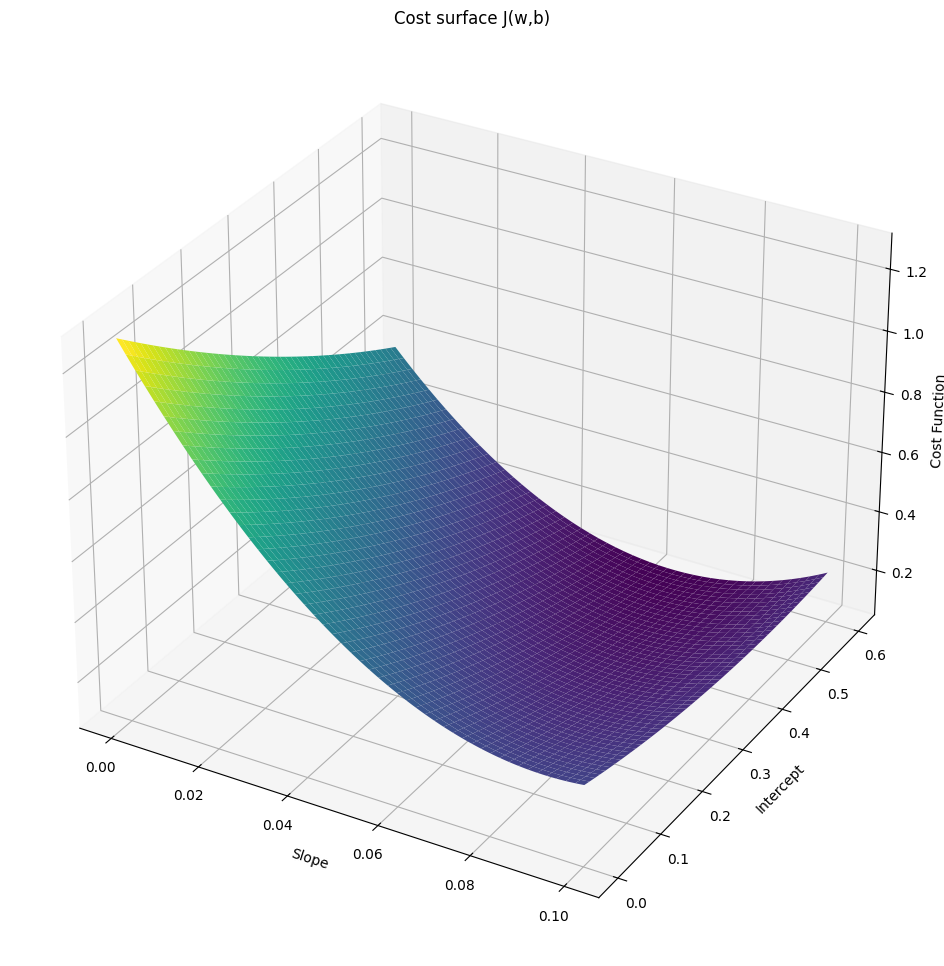

In [131]:
w_values = np.linspace(0, 0.1, 1000) # By eye we can determine that the slope can't be greater tha 0.1
b_values = np.linspace(0, 0.6, 1000) # b < 0.6

W, B = np.meshgrid(w_values, b_values)
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_cost(np.array(stellar_luminosity),
        np.array(stellar_mass), W[i, j], B[i, j])

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0, antialiased=True)
ax.set_xlabel("Slope")
ax.set_ylabel("Intercept")
ax.set_zlabel("Cost Function")
ax.set_title("Cost surface J(w,b)")
plt.show()

In [132]:
# Calculate Minimum Cost
cost_min = np.min(J_vals)

# Calculate (i,j) of the minimum cost
i_min, j_min = np.unravel_index(np.argmin(J_vals), J_vals.shape)

# Calculate w and b according to the minimum cost
w_min = W[i_min, j_min]
b_min = B[i_min, j_min]

print("J_min:", cost_min)
print("w_min:", w_min)
print("b_min:", b_min)


J_min: 0.07231384913441972
w_min: 0.06506506506506507
b_min: 0.6


By evaluating the cost function over a grid of w and b values, a 3D surface is obtained showing how the cost varies with the model parameters. The minimum value of the surface corresponds to the lowest cost found within the explored parameter range, with J aproximately 0.0723 at w = 0.065 and b = 0.6. However, since the minimum occurs at the boundary of the b range, this suggests that the global minimum may lie outside the explored domain. Therefore, the parameter range should be extended to properly locate the true minimum.

# Gradients

In [133]:
def compute_gradients(x, y, w, b):
    m = x.shape[0]
    y_hat = w * x + b
    errors = y_hat - y
    dj_dw = (1 / m) * np.sum(errors * x)
    dj_db = (1 / m) * np.sum(errors)
    return dj_dw, dj_db

# Gradient descent


In [134]:

def gradient_descent(x, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)
        history.append((i, cost))
    return w, b, history

For this study case, we are going to start with a learning rate of 0.01 and do 2000 iterations to see the results. In this case w and b are going to be 0 beacuse the prediction is automatized.

In [135]:
alpha = 0.01
num_iterations = 2000

w_init = 0.0
b_init = 0.0

w_learned, b_learned, history = gradient_descent(np.array(stellar_luminosity), np.array(stellar_mass), w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)


Learned parameters:
w = -1.2114808828494722e+265
b = -5.344225915124378e+263


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-63329435.py:8: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)


For a learning rate of α = 0.01, the cost increases rapidly and numerical overflow occurs during the computation of the squared errors.

# Converge


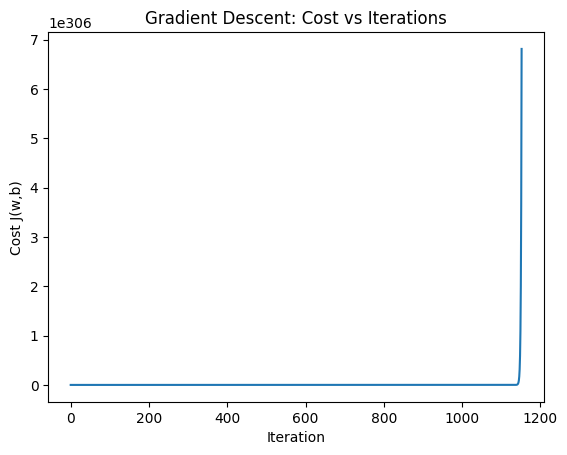

In [136]:
iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent: Cost vs Iterations")
plt.show()

With α=0.01, the loss does not decrease over iterations; instead, it eventually grows explosively, indicating divergence rather than convergence. Therefore, there is no meaningful convergence speed to report. The optimization is unstable, consistent with an overly large learning rate that causes overshooting and numerical instability. For this reason is important to decrease the learning rate

# Eperiments


## α = 0.001

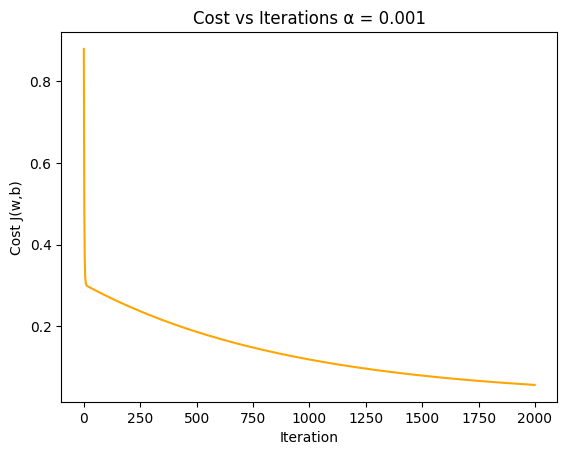

In [137]:
alpha = 0.001
w_learned, b_learned, history = gradient_descent(np.array(stellar_luminosity), np.array(stellar_mass), w_init, b_init, alpha, num_iterations)

iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs, color="orange")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations α = 0.001")
plt.show()

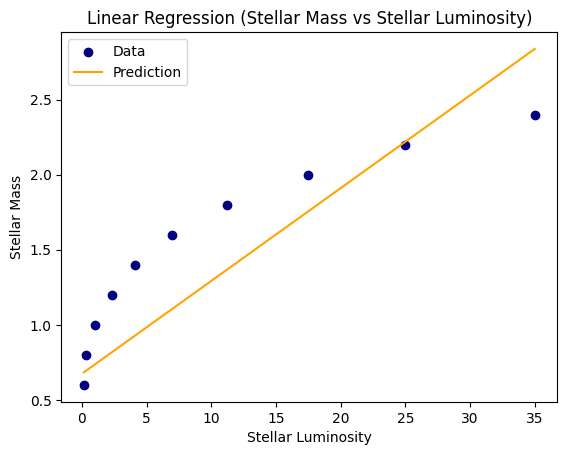


Learned parameters:
w = 0.061783946670583546
b = 0.6744826932371881
Cost α=0.001: 0.05696618108194595


In [138]:
plt.figure()
plt.scatter(np.array(stellar_luminosity), np.array(stellar_mass), label="Data", color="navy")
y_pred = predict(np.array(stellar_luminosity), w_learned, b_learned)
plt.plot(np.array(stellar_luminosity), y_pred, label="Prediction", color = "orange")
plt.xlabel("Stellar Luminosity")
plt.ylabel("Stellar Mass")
plt.title("Linear Regression (Stellar Mass vs Stellar Luminosity)")
plt.legend()
plt.show()
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)
print("Cost α=0.001:",compute_cost(np.array(stellar_luminosity), np.array(stellar_mass),w_learned,b_learned))

## α = 0.002

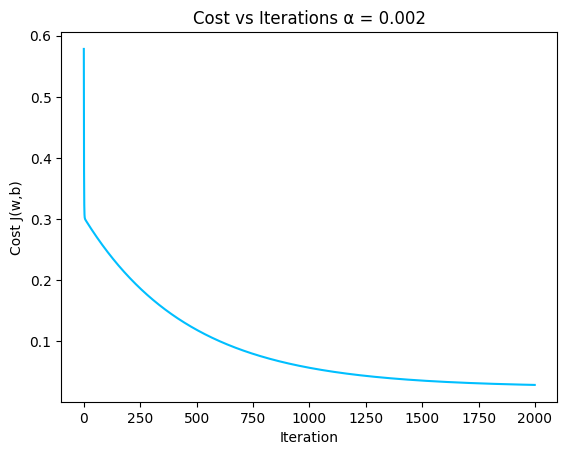

In [139]:
alpha = 0.002
w_learned, b_learned, history = gradient_descent(np.array(stellar_luminosity), np.array(stellar_mass), w_init, b_init, alpha, num_iterations)

iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs, color="deepskyblue")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations α = 0.002")
plt.show()

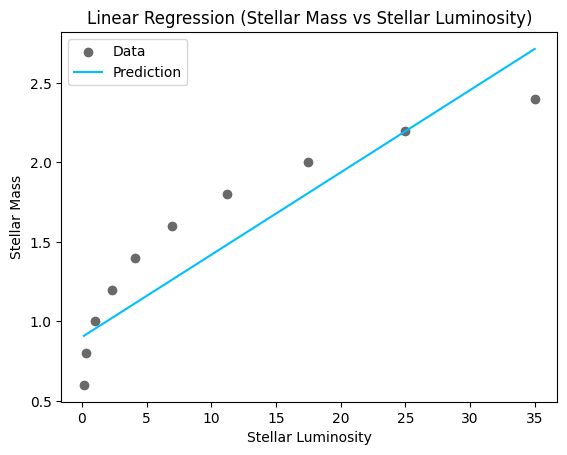


Learned parameters:
w = 0.05179992100160884
b = 0.9008102554311935
Cost α=0.002: 0.028849424206167748


In [140]:
plt.figure()
plt.scatter(np.array(stellar_luminosity), np.array(stellar_mass), label="Data", color="dimgray")
y_pred = predict(np.array(stellar_luminosity), w_learned, b_learned)
plt.plot(np.array(stellar_luminosity), y_pred, label="Prediction", color = "deepskyblue")
plt.xlabel("Stellar Luminosity")
plt.ylabel("Stellar Mass")
plt.title("Linear Regression (Stellar Mass vs Stellar Luminosity)")
plt.legend()
plt.show()
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)
print("Cost α=0.002:",compute_cost(np.array(stellar_luminosity), np.array(stellar_mass),w_learned,b_learned))

## α = 0.0001

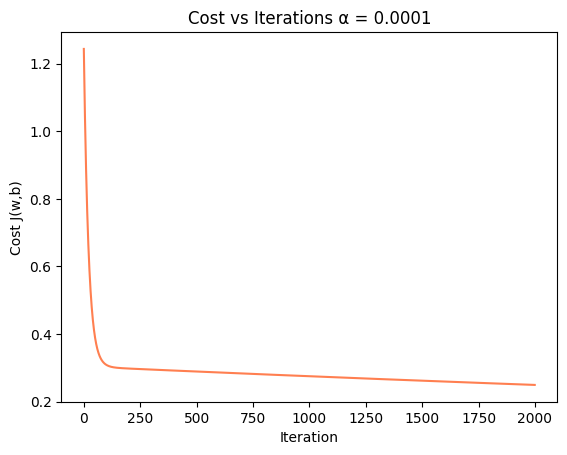

In [141]:
alpha = 0.0001
w_learned, b_learned, history = gradient_descent(np.array(stellar_luminosity), np.array(stellar_mass), w_init, b_init, alpha, num_iterations)

iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs, color="coral")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations α = 0.0001")
plt.show()

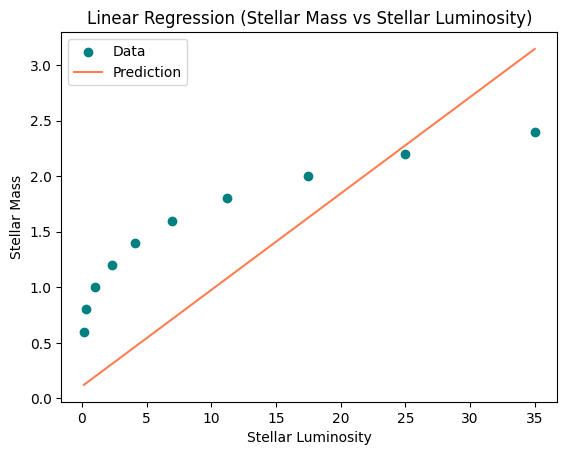


Learned parameters:
w = 0.0867656845085681
b = 0.10817246811319603
Cost α=0.0001: 0.24942409180293348


In [142]:
plt.figure()
plt.scatter(np.array(stellar_luminosity), np.array(stellar_mass), label="Data", color="teal")
y_pred = predict(np.array(stellar_luminosity), w_learned, b_learned)
plt.plot(np.array(stellar_luminosity), y_pred, label="Prediction", color = "coral")
plt.xlabel("Stellar Luminosity")
plt.ylabel("Stellar Mass")
plt.title("Linear Regression (Stellar Mass vs Stellar Luminosity)")
plt.legend()
plt.show()
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)
print("Cost α=0.0001:",compute_cost(np.array(stellar_luminosity), np.array(stellar_mass),w_learned,b_learned))

## Conclusion
For this dataset, the best learning rate is α=0.002, yielding a final cost of approximately 0.0288. Nevertheless, we can observe that the fitted regression line closely matches only two of the data points.

# Conceptual Questions

*   **Astrophysical meaning of w:** w indicates the rate of change of the stellar mass with respect to its luminosity
*   **Why is a linear model limited here?:** Beacuse the relationship between stellar luminosity and stellar mass is not linear, so always the prediction will have a high error rate.

